# Multi-Factor Momentum Trading Strategy

### Part 1: Market Regime Filter
- #### Mechanism: It checks if the market index (e.g., SPY) is trading above its 200-day Simple Moving Average (SMA).
- #### Action: Long positions are only initiated or held if the market is in a bullish regime (price > 200-day SMA). If the market enters a bearish regime, all positions are exited to mitigate systemic risk.

In [295]:
import pandas as pd
import numpy as np 
import requests
from io import StringIO

WIKI_URL = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
TABLE_INDEX = 0  # first table on the page is the constituent list
TICKER_COL = "Symbol"

headers = {"User-Agent": "Mozilla/5.0"}  # wikipedia blocks default requests UA sometimes
resp = requests.get(WIKI_URL, headers=headers, timeout=15)

tables = pd.read_html(StringIO(resp.text))

df = tables[TABLE_INDEX]

tickers = df[TICKER_COL].astype(str).str.strip().tolist()
tickers = [t.replace(".", "-") for t in tickers]
tickers = sorted(set(tickers))
len(tickers)

503

In [296]:
# Doing a small sample for now 
import random 
random.seed(42)
random.shuffle(tickers)
tickers = tickers[:75]

In [297]:
if 'SPY' not in tickers: tickers += ['SPY']

In [298]:
import yfinance as yf
import datetime as dt 

N_YEARS = 10
period = dict(
    start = dt.datetime.today() - dt.timedelta(days=365 * N_YEARS)
    , end   = dt.datetime.today()
)

data = yf.download(tickers, **period)

data.head()

[*********************100%***********************]  76 of 76 completed


Price           Close                                                         \
Ticker            ABT       ADBE       ALGN        APH        ARE       AVGO   
Date                                                                           
2016-07-14  35.274632  97.699997  83.250000  13.305014  72.171806  12.325857   
2016-07-15  35.124454  97.830002  82.419998  13.462212  72.109215  12.354218   
2016-07-18  35.116116  97.790001  82.870003  13.459932  72.707382  12.443907   
2016-07-19  34.874168  97.790001  82.980003  13.341461  72.978653  12.305926   
2016-07-20  35.583336  98.400002  83.410004  13.482716  73.945503  12.469974   

Price                                                     ...   Volume  \
Ticker             AZO       BALL         BG       BRK-B  ...     SWKS   
Date                                                      ...            
2016-07-14  805.179993  32.020374  45.108734  145.729996  ...  2088400   
2016-07-15  799.140015  31.450027  45.511299  145.970001  ...  1791400   
2016-07-18  796.380005  31.405113  45.585850  146.570007  ...  1951400   
2016-07-19  795.659973  31.333254  45.272747  146.919998  ...  1464400   
2016-07-20  800.039978  31.679058  45.787125  146.169998  ...  3220800   

Price                                                                          \
Ticker         TDG      TJX      TMO     TRMB      TSLA    VEEV VLTO      WDC   
Date                                                                            
2016-07-14  335900  5342400  2033500   862100  40137000  753300  NaN  4791774   
2016-07-15  342400  5143400  1628200   898500  33513000  772400  NaN  4149325   
2016-07-18  397600  7778000  1098900  1320200  51181500  637300  NaN  3907481   
2016-07-19  485600  5219000   679200   960600  46726500  849400  NaN  5050023   
2016-07-20  298200  4877000   686900  1222500  38527500  974900  NaN  5524583   

Price                
Ticker          WSM  
Date                 
2016-07-14  3238600  
2016-07-15  3255800  
2016-07-18  2458800  
2016-07-19  1836000  
2016-07-20  1539000  

[5 rows x 380 columns]

In [299]:
assert not data.empty

In [300]:
assert not data.Close.isna().all(axis=0).sum() 

In [301]:
# Market Regime Filter
LOOKBACK_REGIME = 200
spy_sma_200 = data.Close.SPY.rolling(LOOKBACK_REGIME).mean()
mrf_signal = data.Close.SPY < spy_sma_200

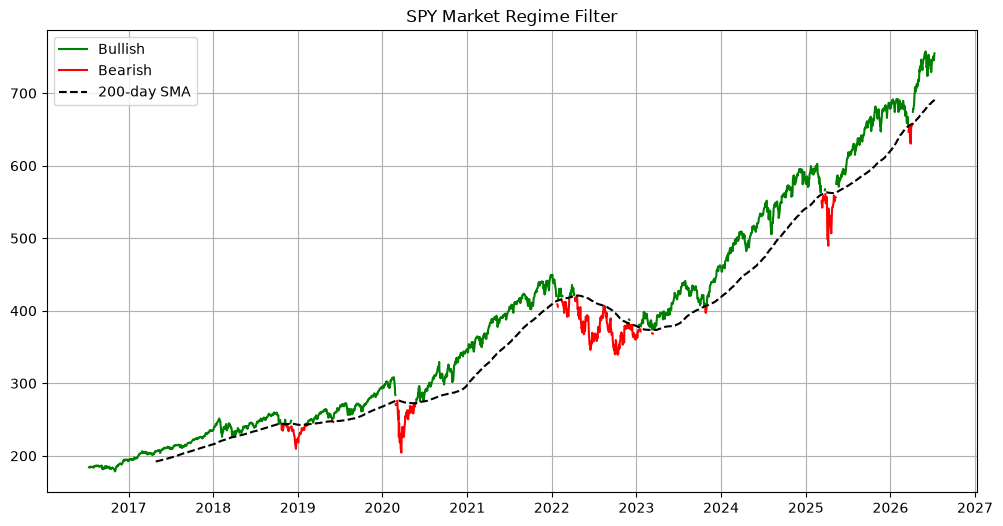

In [302]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Plot SPY price when filter is ON (green)
plt.plot(
    data.index,
    data.Close.SPY.where(~mrf_signal),
    color="green",
    label="Bullish"
)

# Plot SPY price when filter is OFF (red)
plt.plot(
    data.index,
    data.Close.SPY.where(mrf_signal),
    color="red",
    label="Bearish"
)

# Optional: plot the 200-day SMA
plt.plot(
    data.index,
    spy_sma_200,
    color="black",
    linestyle="--",
    label="200-day SMA"
)

plt.title("SPY Market Regime Filter")
plt.legend()
plt.grid(True)
plt.show()

### Part 2: Time-Series Momentum (TSMOM): This is a trend-following filter applied to each individual stock.
- #### Mechanism: A stock is only considered a candidate for investment if it is trading above its own 200-day SMA.

In [303]:
LOOK_BACK_TSMOM = 200
def sma_200(x: pd.Series) -> pd.Series:
    return x.rolling(LOOK_BACK_TSMOM).mean()

data_sma_200d = data.Close.apply(sma_200)
data_sma_200d.tail()

Ticker,ABT,ADBE,ALGN,APH,ARE,AVGO,AZO,BALL,BG,BRK-B,...,SWKS,TDG,TJX,TMO,TRMB,TSLA,VEEV,VLTO,WDC,WSM
Date,,,,,,,,,,,,,,,,,,,,,
2026-07-06,110.777188,288.00320,162.283599,138.623211,53.123445,360.281290,3589.096146,55.599239,107.643887,490.32530,...,65.015693,1284.589749,152.477174,525.699493,69.87255,418.59850,212.954850,94.657228,292.786009,194.717729
2026-07-07,110.596017,287.30055,162.562499,138.827404,52.969239,360.416930,3583.307598,55.669948,107.803970,490.38365,...,64.953738,1284.858099,152.553781,525.925863,69.74300,418.48370,212.543451,94.591858,294.942587,194.857543
2026-07-08,110.409577,286.56795,162.773049,139.011447,52.797295,360.646190,3577.994297,55.728015,107.988155,490.40510,...,64.873132,1284.909649,152.624333,526.077599,69.59670,418.36975,212.088901,94.518096,297.169147,194.961617
2026-07-09,110.212002,285.85170,163.006949,139.206289,52.633640,360.939585,3572.344447,55.792055,108.167872,490.41810,...,64.790528,1284.975899,152.686178,526.309815,69.44635,418.27215,211.648451,94.446930,299.527069,195.079719
2026-07-10,110.009222,285.14950,163.248299,139.386475,52.468249,361.254925,3567.102646,55.859645,108.361047,490.41810,...,64.690605,1284.956199,152.752057,526.576617,69.29970,418.13990,211.193451,94.384136,301.878836,195.215586


In [304]:
tsmom_filter = data.Close.gt(data_sma_200d)

<Axes: title={'center': 'Number of Stocks Above 200-Day SMA'}, xlabel='Date', ylabel='Number of Valid Stocks'>

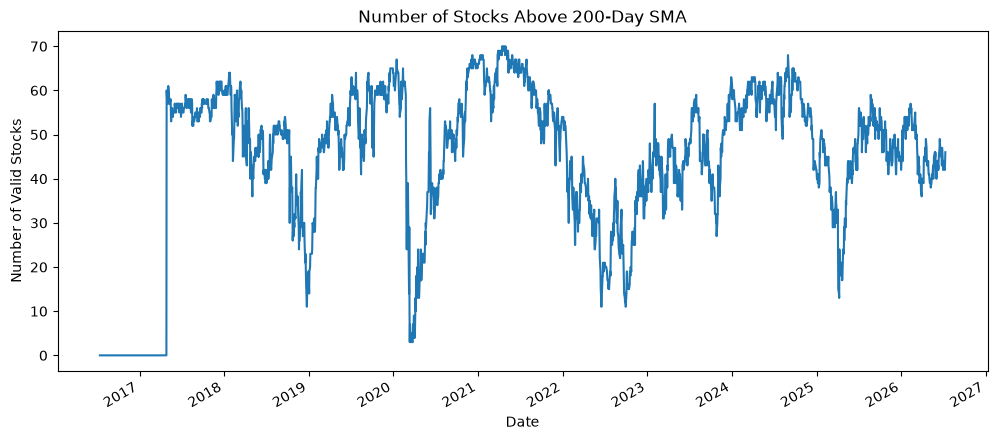

In [305]:
valid_stocks = tsmom_filter.sum(axis=1)

valid_stocks.plot(
    figsize=(12, 5),
    title="Number of Stocks Above 200-Day SMA",
    ylabel="Number of Valid Stocks",
    xlabel="Date"
)

### Part 3: Cross-Sectional Momentum: After filtering for trend, stocks are ranked against each other based on their momentum.
- #### Mechanism: Momentum is calculated over multiple lookback periods (60, 120, and 252 days) and then averaged to produce a robust momentum score.

In [306]:

cross_sect_mom_lookbacks = [60, 120, 252]
LOOKBACK_CSM = max(cross_sect_mom_lookbacks)

def cross_sect_mom(prices: pd.DataFrame, lookbacks: list[int] = cross_sect_mom_lookbacks) -> pd.DataFrame:
    # average raw return signal per asset, per lookback
    raw_signal = pd.concat(
        [(prices / prices.shift(l)) - 1 for l in lookbacks]
    ).groupby(level=0).mean()  # or however you're aligning — see note below

    # cross-sectional z-score: rank/normalize ACROSS assets at each date
    z = raw_signal.sub(raw_signal.mean(axis=1), axis=0).div(raw_signal.std(axis=1), axis=0)
    return z

csm_data = cross_sect_mom(data.Close)
csm_data.tail()

Ticker,ABT,ADBE,ALGN,APH,ARE,AVGO,AZO,BALL,BG,BRK-B,...,SWKS,TDG,TJX,TMO,TRMB,TSLA,VEEV,VLTO,WDC,WSM
Date,,,,,,,,,,,,,,,,,,,,,
2026-07-06,-0.317703,-0.374489,-0.180560,0.023329,-0.248549,-0.092869,-0.298589,-0.154208,-0.135946,-0.177928,...,-0.206912,-0.198494,-0.177760,-0.186638,-0.380365,-0.103911,-0.276418,-0.236699,1.870919,-0.074722
2026-07-07,-0.325887,-0.374155,-0.186732,-0.016504,-0.257785,-0.103245,-0.301532,-0.155885,-0.100664,-0.184665,...,-0.227513,-0.209057,-0.168270,-0.186087,-0.386475,-0.129422,-0.264277,-0.234997,1.802601,-0.081943
2026-07-08,-0.306515,-0.341795,-0.210342,-0.035936,-0.252397,-0.082373,-0.281526,-0.175157,-0.066609,-0.184578,...,-0.224147,-0.213415,-0.166358,-0.178796,-0.372007,-0.127375,-0.250484,-0.231926,1.730610,-0.092616
2026-07-09,-0.305155,-0.340769,-0.206678,-0.026286,-0.257654,-0.059527,-0.286554,-0.176168,-0.092075,-0.183312,...,-0.217325,-0.222683,-0.169287,-0.177922,-0.364912,-0.113317,-0.246472,-0.230764,1.767724,-0.097308
2026-07-10,-0.301930,-0.327192,-0.210872,-0.058857,-0.270854,-0.070776,-0.271747,-0.164158,-0.092058,-0.182498,...,-0.208130,-0.231609,-0.168372,-0.175307,-0.355495,-0.115949,-0.244341,-0.228770,1.697947,-0.101243


<Axes: title={'center': 'Cross-Sectional Momentums'}, xlabel='Date'>

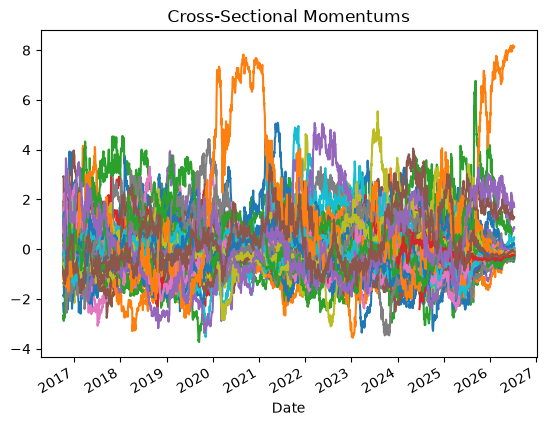

In [307]:
csm_data.plot(
    title='Cross-Sectional Momentums'
    , legend=False
)

### Part 4: Frog-in-the-Pan (FIP) Score: This factor measures the quality and consistency of a stock's trend.
- #### Mechanism: It calculates the ratio of positive daily returns over a 252-day period. A higher score indicates a smoother, more consistent uptrend, rather than one driven by a few large, volatile spikes.


In [308]:
LOOK_BACK_FIP = 252
daily_ret = (data.Close / data.Close.shift(1)) - 1
is_positive = daily_ret > 0
# Return was positive how many days
positive_days_sum = is_positive.rolling(LOOK_BACK_FIP).sum()
# Ratio of positive return days/total days
fip_data = positive_days_sum / 252
fip_data.tail()

Ticker,ABT,ADBE,ALGN,APH,ARE,AVGO,AZO,BALL,BG,BRK-B,...,SWKS,TDG,TJX,TMO,TRMB,TSLA,VEEV,VLTO,WDC,WSM
Date,,,,,,,,,,,,,,,,,,,,,
2026-07-06,0.468254,0.464286,0.496032,0.571429,0.543651,0.523810,0.496032,0.500000,0.476190,0.496032,...,0.480159,0.535714,0.515873,0.488095,0.527778,0.531746,0.484127,0.440476,0.607143,0.515873
2026-07-07,0.468254,0.464286,0.496032,0.567460,0.539683,0.519841,0.496032,0.500000,0.480159,0.492063,...,0.476190,0.531746,0.515873,0.484127,0.527778,0.531746,0.484127,0.440476,0.603175,0.511905
2026-07-08,0.468254,0.464286,0.496032,0.567460,0.539683,0.523810,0.492063,0.500000,0.484127,0.492063,...,0.476190,0.527778,0.515873,0.484127,0.527778,0.531746,0.484127,0.440476,0.607143,0.511905
2026-07-09,0.468254,0.464286,0.496032,0.571429,0.539683,0.527778,0.492063,0.500000,0.480159,0.496032,...,0.476190,0.523810,0.511905,0.484127,0.527778,0.531746,0.488095,0.444444,0.611111,0.515873
2026-07-10,0.468254,0.468254,0.496032,0.567460,0.535714,0.523810,0.492063,0.503968,0.484127,0.492063,...,0.480159,0.523810,0.511905,0.488095,0.527778,0.535714,0.488095,0.444444,0.611111,0.515873


<Axes: title={'center': 'Frog in the Pan Scores'}, xlabel='Date'>

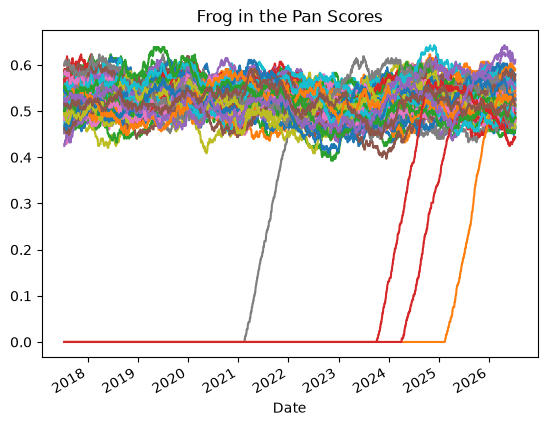

In [309]:
fip_data.plot(
    title='Frog in the Pan Scores'
    , legend=False
)

### Part 5: Skewness Factor: To mitigate the risk of holding stocks prone to sudden crashes, a skewness factor is included.
- #### Mechanism: It calculates the rolling skewness of stock returns over a 90-day window. A high negative skew suggests a stock has a "tail" of large negative returns and is thus penalized in its final score.

In [310]:
LOOKBACK_SKEW = 90
log_returns = np.log(data.Close).diff()
skew_data = log_returns.rolling(LOOKBACK_SKEW).skew()
skew_data.tail()

Ticker,ABT,ADBE,ALGN,APH,ARE,AVGO,AZO,BALL,BG,BRK-B,...,SWKS,TDG,TJX,TMO,TRMB,TSLA,VEEV,VLTO,WDC,WSM
Date,,,,,,,,,,,,,,,,,,,,,
2026-07-06,0.013093,-0.184058,0.259768,-0.133841,-0.495123,-0.816905,-1.077906,-0.157990,0.163585,-1.026181,...,0.150507,0.121149,-0.119116,-0.569398,-0.601810,0.014486,0.771811,0.432078,-0.340758,0.578355
2026-07-07,0.011907,-0.188199,0.292692,-0.116920,-0.477615,-0.792528,-1.054870,-0.163202,0.124966,-1.009490,...,0.168656,0.140354,-0.158558,-0.572429,-0.590868,0.049546,0.774650,0.434251,-0.311982,0.588177
2026-07-08,0.043887,-0.179443,0.249392,-0.137714,-0.433028,-0.819182,-1.057504,-0.177369,0.124790,-1.012794,...,0.182470,0.177060,-0.123611,-0.537541,-0.542815,0.049965,0.828441,0.377298,-0.349304,0.618374
2026-07-09,0.061271,-0.174801,0.233638,-0.175178,-0.465141,-0.840577,-1.033168,-0.181640,0.161470,-1.006471,...,0.160495,0.164291,-0.084049,-0.538900,-0.584117,0.011489,0.812917,0.354816,-0.377919,0.605261
2026-07-10,0.045184,-0.187038,0.218344,-0.053803,-0.478420,-0.839929,-1.076110,-0.212696,0.150135,0.514058,...,0.143456,0.187126,-0.111764,-0.578852,-0.588552,0.010398,0.806785,0.334265,-0.403761,0.579562


In [ ]:
CLOSE         : int = 0
MRF_SIGNAL    : int = 1
TSMOM_SIGNALS : int = 2
CSM_SIGNALS   : int = 3
FIP_SCORES    : int = 4
SKEWS         : int = 5

strat_dat = (
    data.Close
    , mrf_signal 
    , tsmom_filter
    , csm_data
    , fip_data
    , skew_data
)

common_start = min(df.dropna().index[0] for df in strat_dat)
datas = [d[common_start:] for d in strat_dat]

In [ ]:
SELL_ALL_SIGNAL    : str = 'SELL_ALL_SIGNAL'
BASKET_EMPTY_SIGNAL: str = 'BASKET_EMPTY_SIGNAL'
NO_CSM_SIGNAL      : str = 'NO_CSM_SIGNAL'

TOP_N : int = 10
d = strat_dat[CLOSE].index[-1]

signal_df = pd.DataFrame(
      columns = [
          SELL_ALL_SIGNAL
          , BASKET_EMPTY_SIGNAL
          , *strat_dat[CLOSE].columns
        ]
    , index   = strat_dat[CLOSE].index
).fillna(0)

def build_signal(d: pd.Timestamp):
    ### Part 1: Market Regime Filter
    #### Mechanism: It checks if the market index (e.g., SPY) is trading above its 200-day Simple Moving Average (SMA).
    #### Action: Long positions are only initiated or held if the market is in a bullish regime (price > 200-day SMA). 
    #### If the market enters a bearish regime, all positions are exited to mitigate systemic risk.
    if strat_dat[MRF_SIGNAL].loc[d]:
        signal_df.loc[d, SELL_ALL_SIGNAL] = 1
        return
    
    ### Part 2: Time-Series Momentum (TSMOM): This is a trend-following filter applied to each individual stock.
    #### Mechanism: A stock is only considered a candidate for investment if it is trading above its own 200-day SMA.
    basket = strat_dat[CLOSE].columns[ 
        strat_dat[TSMOM_SIGNALS].loc[d]
    ]
    
    if basket.empty: 
        signal_df.loc[d, BASKET_EMPTY_SIGNAL] = 1
        return
    
    ### Part 3: Cross-Sectional Momentum: After filtering for trend, stocks are ranked against each other based on their momentum.
    #### Mechanism: Momentum is calculated over multiple lookback periods 
    #### (60, 120, and 252 days) and then averaged to produce a robust momentum score.
    csm = strat_dat[CSM_SIGNALS].loc[d][basket]
    csm = csm[csm>0].nlargest(TOP_N)
    
    if csm.empty:
        signal_df.loc[d, NO_CSM_SIGNAL] = 1
        return

    winners = csm.index

    ### Part 4: Frog-in-the-Pan (FIP) Score: 
    #### This factor measures the quality and consistency of a stock's trend.
    #### Mechanism: It calculates the ratio of positive daily returns over a 252-day period. 
    #### A higher score indicates a smoother, more consistent uptrend, 
    #### rather than one driven by a few large, volatile spikes.
    fip  = strat_dat[FIP_SCORES].loc[d, winners]

    ### Part 5: Skewness Factor: To mitigate the risk of holding stocks prone to sudden crashes, a skewness factor is included.
    #### Mechanism: It calculates the rolling skewness of stock returns over a 90-day window. 
    #### A high negative skew suggests a stock has a "tail" of large negative returns and is thus penalized in its final score.
    skew = strat_dat[SKEWS].loc[d, winners]
    
    ### Part 6: Inverse Volatility Weighting: This is a risk parity approach to portfolio construction.
    #### Mechanism: Once the top N stocks are selected, portfolio capital is allocated 
    #### inversely proportional to each stock's historical volatility (standard deviation over 126 days).
    #### Less volatile stocks receive a larger capital allocation, and more volatile stocks receive a smaller one,
    ####  with the goal of equalizing the risk contribution of each position.
    # w_i = (1 / σ_i) / Σ (1 / σ_j)

    # TODO 

build_signal(d)

[np.float64(inf), np.float64(inf), np.float64(inf), np.float64(inf), np.float64(inf), np.float64(inf), np.float64(inf), np.float64(inf), np.float64(inf), np.float64(inf)]


/tmp/ipykernel_10302/1151987398.py:69: RuntimeWarning: divide by zero encountered in scalar divide
  (1 / strat_dat[CLOSE].loc[d, w].std())


### Part 6: Inverse Volatility Weighting: This is a risk parity approach to portfolio construction.
- #### Mechanism: Once the top N stocks are selected, portfolio capital is allocated inversely proportional to each stock's historical volatility (standard deviation over 126 days). Less volatile stocks receive a larger capital allocation, and more volatile stocks receive a smaller one, with the goal of equalizing the risk contribution of each position.